In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import config
import utils
import pickle

from sklearn.base import clone
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, RocCurveDisplay, auc,
                             recall_score, precision_score, accuracy_score, f1_score,
                             make_scorer, fbeta_score)
from sklearn.model_selection import StratifiedKFold, learning_curve, TunedThresholdClassifierCV

import shap

In [2]:
df = utils.get_cleaned_dataset()
X, y = df.drop(columns=["target", "diagnosis"]), df["target"]
results: pd.DataFrame = pd.read_pickle(config.DATA_DIR / "nested_cv_results.pkl")

In [3]:
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   model                         60 non-null     str    
 1   best_estimator                60 non-null     object 
 2   outer_fold                    60 non-null     int64  
 3   y_true                        60 non-null     object 
 4   y_pred                        60 non-null     object 
 5   y_proba                       60 non-null     object 
 6   search_type                   60 non-null     str    
 7   recall                        60 non-null     float64
 8   precision                     60 non-null     float64
 9   accuracy                      60 non-null     float64
 10  f1                            60 non-null     float64
 11  inner_best_score              50 non-null     float64
 12  inner_mean_validation_score   50 non-null     float64
 13  inner_std_validati

In [4]:
models = results["model"].unique()
search_types = results["search_type"].unique()
outer_folds = results["outer_fold"].unique()

# 1. Confronto tra approcci di ricerca

## 1.1 Confronto prestazioni e tempo di addestramento

Si confrontano le prestazioni medie (recall) e il tempo di addestramento tra Grid Search e Random Search, per ciascun modello, aggregando i risultati sui 5 fold esterni della nested cross-validation. L'obiettivo è verificare se Random Search raggiunge prestazioni comparabili a Grid Search a fronte di un tempo di addestramento inferiore, dato lo spazio di ricerca più ampio ma esplorato in modo campionato.

In [7]:
search_results = results.groupby(["model", "search_type"])[['recall', 'fit_time_seconds']].agg(
    recall_mean=('recall', 'mean'),
    recall_std=('recall', 'std'),
    fit_time_mean=('fit_time_seconds', 'mean'),
    fit_time_std=('fit_time_seconds', 'std'),
).reset_index()

In [8]:
search_results

,model,search_type,recall_mean,recall_std,fit_time_mean,fit_time_std
0,KNeighborsClassifier,grid,0.9198,0.066036,24.424,0.590491
1,KNeighborsClassifier,random,0.9152,0.071793,7.302,0.217071
2,LogisticRegression,grid,0.9574,0.042294,37.886,0.707057
3,LogisticRegression,random,0.9574,0.042294,7.512,0.136638
4,RandomForestClassifier,grid,0.9482,0.058157,329.598,5.157836
5,RandomForestClassifier,random,0.9434,0.053626,10.582,0.248133
6,SVC,grid,0.9480,0.045755,25.172,2.980423
7,SVC,random,0.9432,0.039214,7.322,0.093648
8,StackingClassifier,grid,0.9480,0.053838,352.432,6.602675
9,StackingClassifier,random,0.9574,0.042294,55.878,8.342857


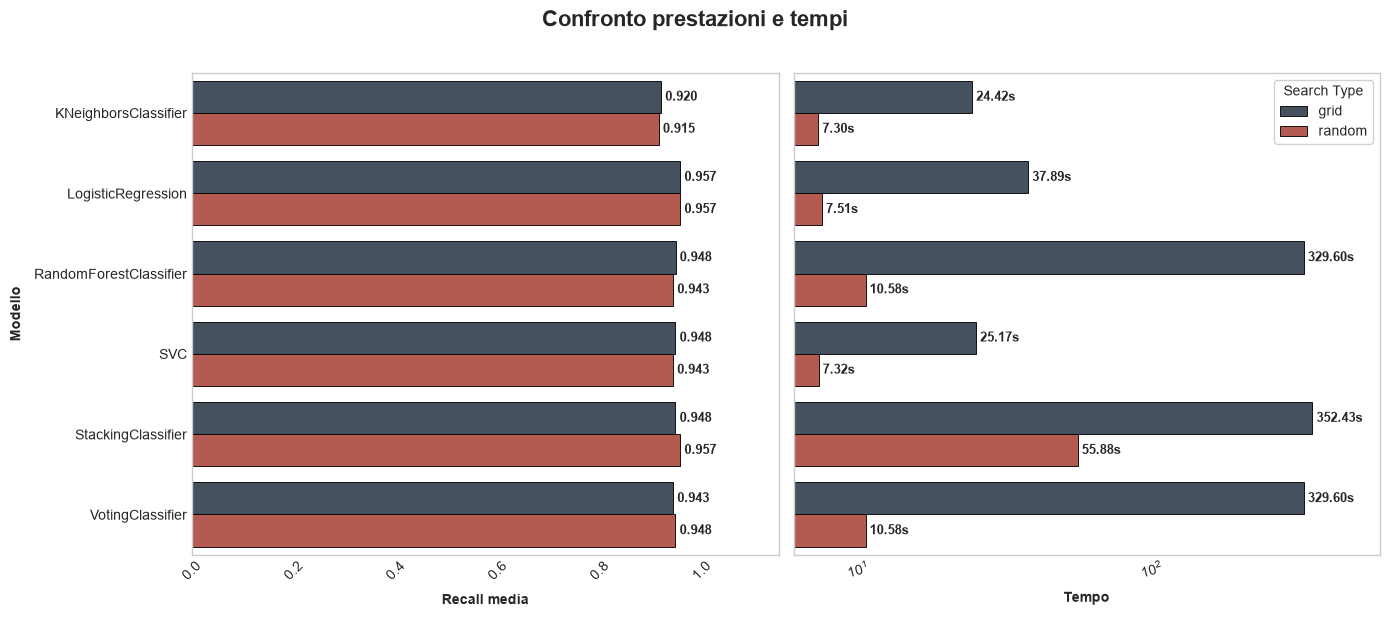

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# grafico recall
sns.barplot(
    data=search_results,
    x="recall_mean",
    y="model",
    hue="search_type",
    palette=config.SEARCH_TYPE_PALETTE,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.9,
    ax=ax1,
)
ax1.set_xlabel("Recall media", fontweight="bold", labelpad=8)
ax1.set_ylabel("Modello", fontweight="bold", labelpad=8)
ax1.set_xlim(0, 1.15)
ax1.tick_params(axis="x", rotation=45)
ax1.grid(False, axis="x")

for container in ax1.containers:
    ax1.bar_label(
        container, fmt="%.3f", padding=3, fontsize=9, fontweight="semibold"
    )


# grafico tempo
sns.barplot(
    data=search_results,
    x="fit_time_mean",
    y="model",
    hue="search_type",
    palette=config.SEARCH_TYPE_PALETTE,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.9,
    ax=ax2,
)
ax2.set_xscale("log")
ax2.set_xlabel("Tempo", fontweight="bold", labelpad=8)
ax2.tick_params(axis="y", labelleft=False)
ax2.set_ylabel("")
ax2.tick_params(axis="x", rotation=15)
ax2.grid(False, axis="x")

max_time = search_results["fit_time_mean"].max()
ax2.set_xlim(right=max_time * 1.70)

for container in ax2.containers:
    ax2.bar_label(
        container, fmt="%.2fs", padding=3, fontsize=9, fontweight="semibold"
    )

ax1.get_legend().remove()
ax2.legend(
    title="Search Type",
    title_fontsize="10",
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    loc="upper right",
)
fig.suptitle("Confronto prestazioni e tempi", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [73]:
# prestazioni medie per modello in funzione dell'outer fold
results.groupby(["outer_fold", "model"])['recall'].mean().unstack("model")

model,KNeighborsClassifier,LogisticRegression,RandomForestClassifier,SVC,StackingClassifier,VotingClassifier
outer_fold,,,,,,
1,0.9770,1.000,1.000,0.9885,1.0000,0.9885
2,0.8485,0.930,0.860,0.9185,0.9185,0.9070
3,0.8570,0.905,0.929,0.8930,0.8930,0.8810
4,1.0000,1.000,0.988,0.9760,1.0000,1.0000
5,0.9050,0.952,0.952,0.9520,0.9520,0.9520


In [75]:
results.groupby(["outer_fold"])['recall'].describe()

,count,mean,std,min,25%,50%,75%,max
outer_fold,,,,,,,,
1,12.0,0.992333,0.011324,0.977,0.977,1.000,1.000,1.000
2,12.0,0.897083,0.033660,0.837,0.860,0.907,0.930,0.930
3,12.0,0.893000,0.024000,0.857,0.881,0.893,0.905,0.929
4,12.0,0.994000,0.014918,0.952,1.000,1.000,1.000,1.000
5,12.0,0.944167,0.018295,0.905,0.952,0.952,0.952,0.952


## 1.2 Matrici di confusione

Di seguito sono riportate le matrici di confusione aggregate out-of-fold per ciascun classificatore, confrontando i risultati ottenuti tramite Grid Search e Random Search. I valori mostrano la distribuzione complessiva delle predizioni corrette ed errate sulle classi diagnostiche (benigno e maligno). In questo contesto i falsi negativi (tumori maligni classificati come benigni) rappresentano l'errore più critico da minimizzare, e sono quindi il valore su cui concentrare l'attenzione nel confronto tra modelli e strategie di ricerca.

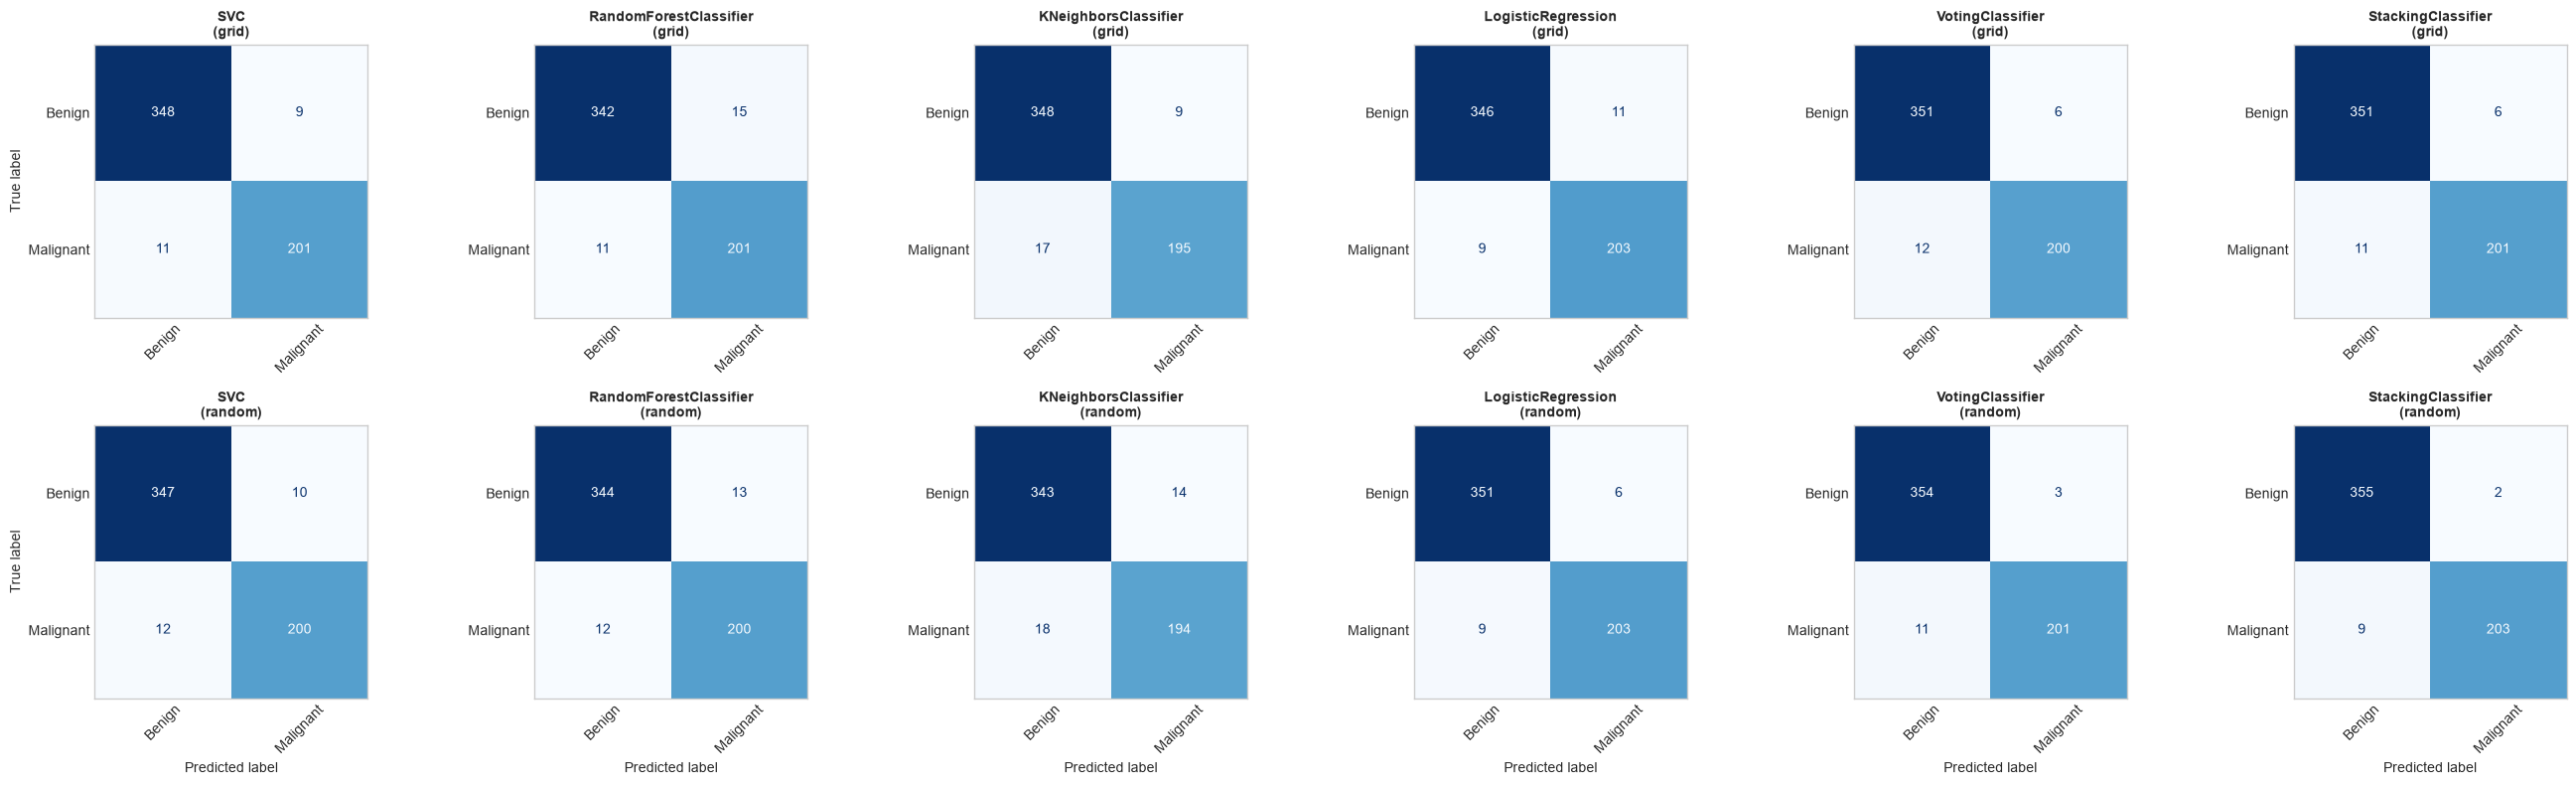

In [12]:
# per ogni modello, per ogni search type, si mostra la confusion matrix aggregata out-of-fold
n_rows = len(search_types)
n_cols = len(models)

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(4.5 * n_cols, 4.0 * n_rows),
    squeeze=False,
)

diagnosis = sorted(df["diagnosis"].unique())

for i, search_type in enumerate(search_types):
    for j, model in enumerate(models):
        ax = axes[i, j]

        sub_df = results.query("model == @model and search_type == @search_type")

        if sub_df.empty:
            ax.axis("off")
            continue

        y_true_all = np.concatenate(sub_df["y_true"].values)
        y_pred_all = np.concatenate(sub_df["y_pred"].values)

        cm = confusion_matrix(y_true_all, y_pred_all)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm, display_labels=diagnosis
        )
        disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")

        ax.set_title(f"{model}\n({search_type})", fontweight="bold", fontsize=10)
        ax.grid(False)

        ax.tick_params(axis="x", rotation=45)

        if j > 0:
            ax.set_ylabel("")
        if i < n_rows - 1:
            ax.set_xlabel("")

plt.tight_layout()
plt.show(fig)

## 1.3 Roc curve

In figura sono riportate le curve ROC e i relativi valori di AUC (Area Under the Curve) per tutti i modelli valutati, confrontando le performance ottenute tramite Grid Search (a sinistra) e Random Search (a destra). Le predizioni sono aggregate sui fold di cross-validation out-of-fold.

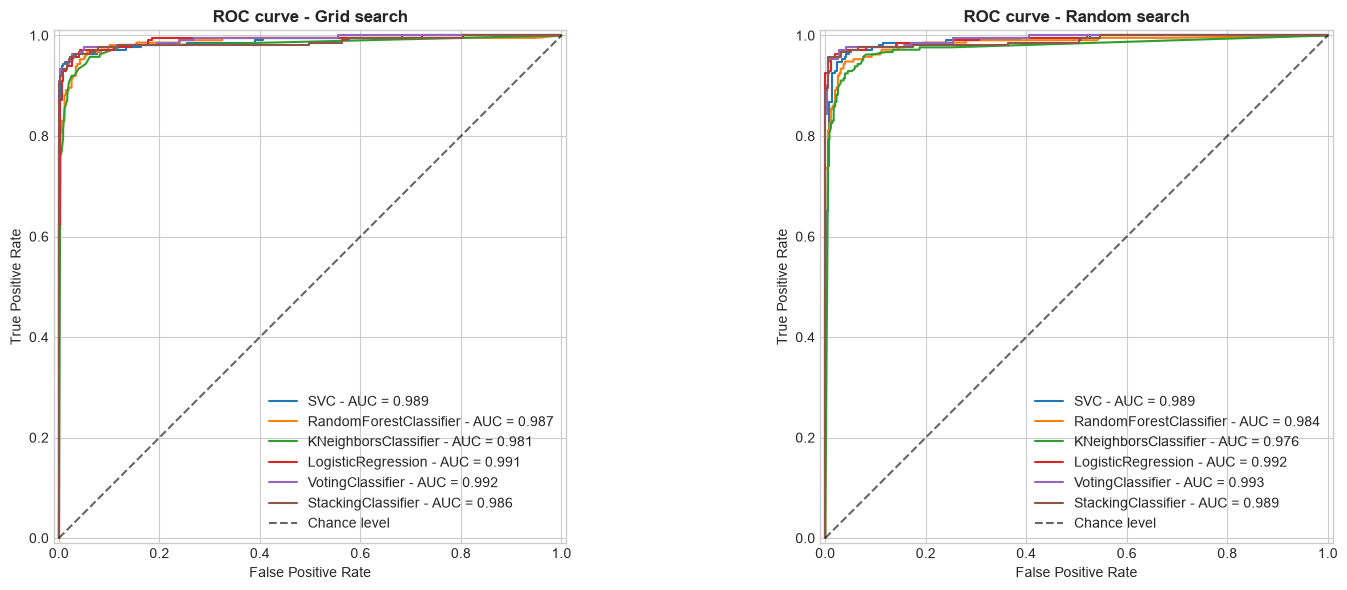

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for model in models:
    df_grid = results.query("model == @model and search_type == 'grid'")
    y_true_grid = np.concatenate(df_grid["y_true"].values)
    y_proba_grid = np.concatenate(df_grid["y_proba"].values)

    fpr, tpr, _ = roc_curve(y_true_grid, y_proba_grid)
    roc_auc_grid = auc(fpr, tpr)

    display_grid = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=None)
    display_grid.plot(
        ax=axes[0],
        name=f"{model} - AUC = {roc_auc_grid:.3f}",
        plot_chance_level=False
    )

    df_random = results.query("model == @model and search_type == 'random'")
    y_true_rand = np.concatenate(df_random["y_true"].values)
    y_proba_rand = np.concatenate(df_random["y_proba"].values)

    fpr, tpr, _ = roc_curve(y_true_rand, y_proba_rand)
    roc_auc_rand = auc(fpr, tpr)

    display_rand = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=None)
    display_rand.plot(
        ax=axes[1],
        name=f"{model} - AUC = {roc_auc_rand:.3f}",
        plot_chance_level=False
    )


for i, search_type in enumerate(search_types):
    axes[i].plot([0, 1], [0, 1], "k--", alpha=0.6, label="Chance level")
    axes[i].set_title(f"ROC curve - {search_type.capitalize()} search", fontweight="bold", fontsize=12)
    axes[i].set_xlabel("False Positive Rate")
    axes[i].set_ylabel("True Positive Rate")
    axes[i].legend(loc="lower right")


plt.tight_layout()
plt.show(fig)

## 1.4 Learning curves

In basso sono riportate le learning curve medie per ciascun modello, confrontando l'andamento ottenuto tramite Grid Search e Random Search all'aumentare della dimensione del training set. Le curve tracciano il punteggio di recall su train e validation set, con la deviazione standard tra i fold esterni rappresentata come banda d'ombra. L'obiettivo è individuare eventuali segnali di overfitting (gap ampio e persistente tra train e validation) o di underfitting (entrambe le curve basse e piatte).

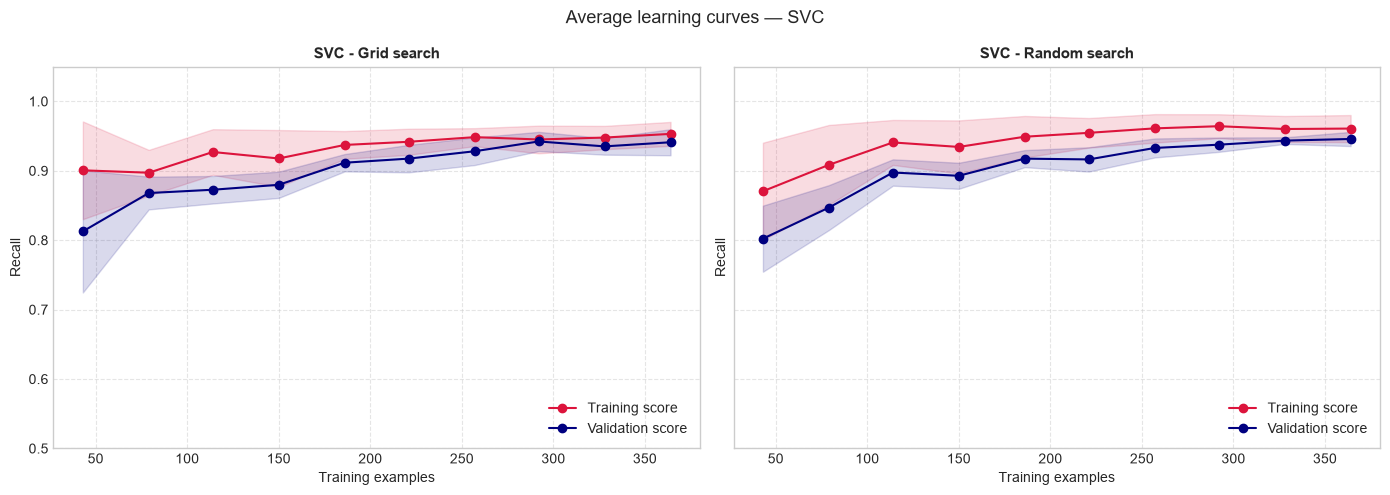

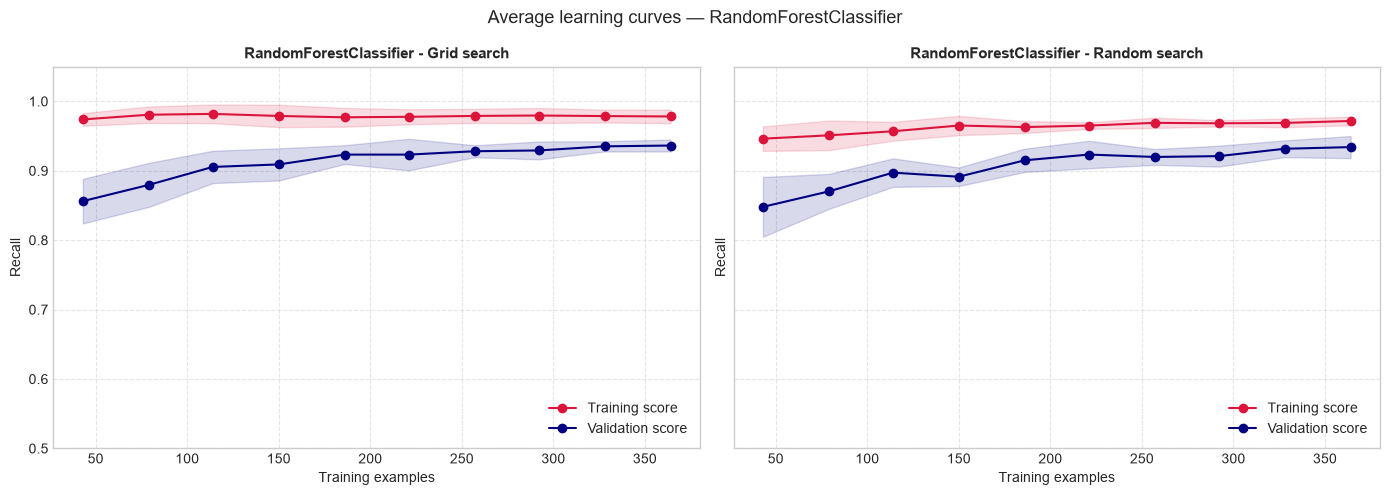

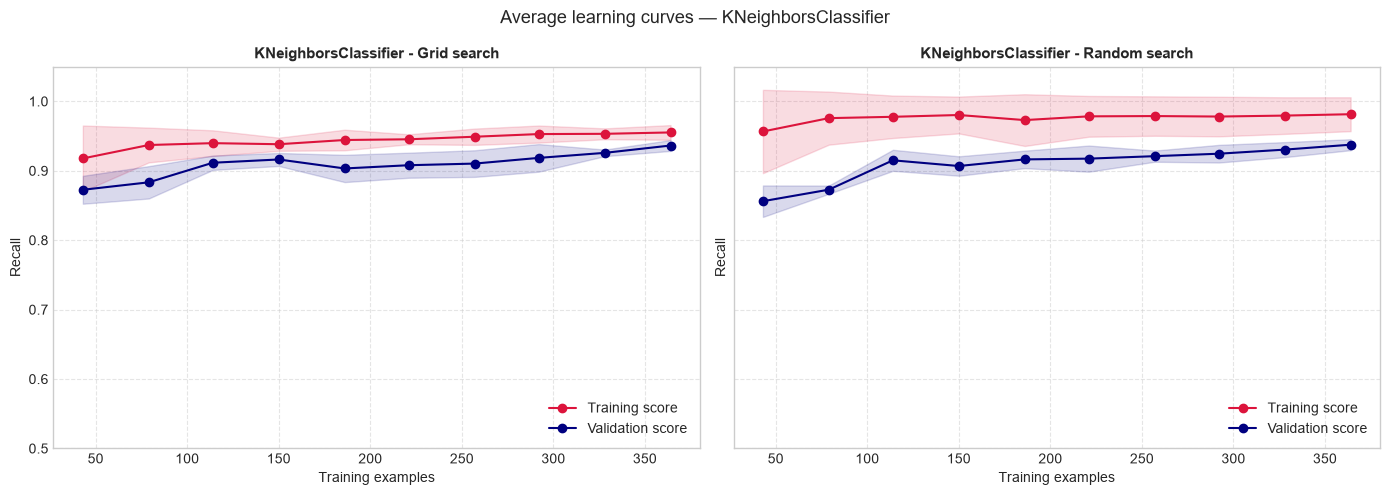

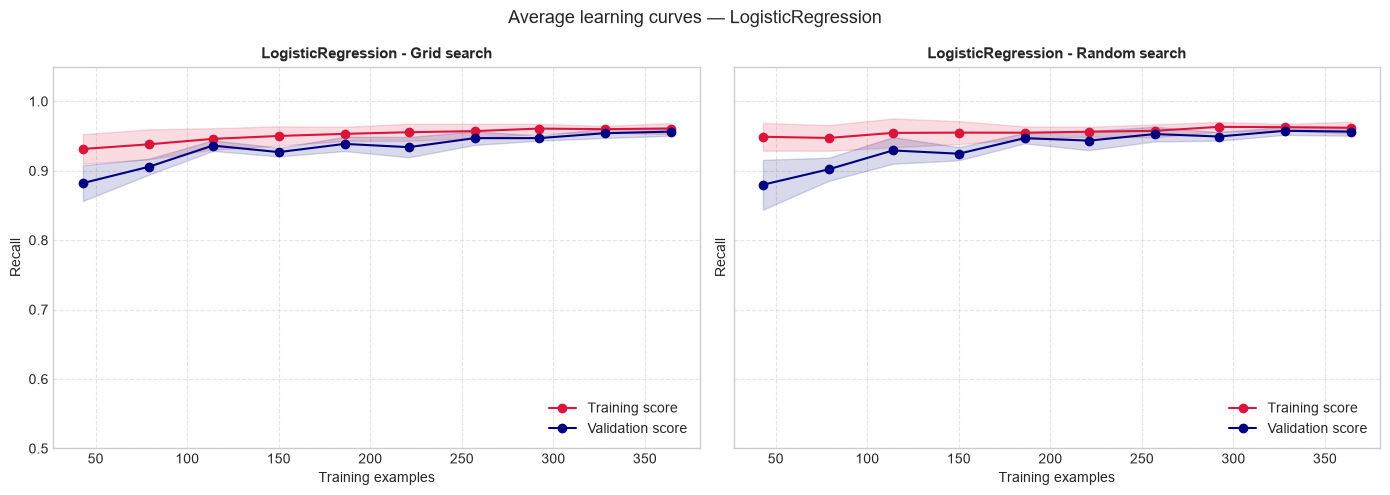

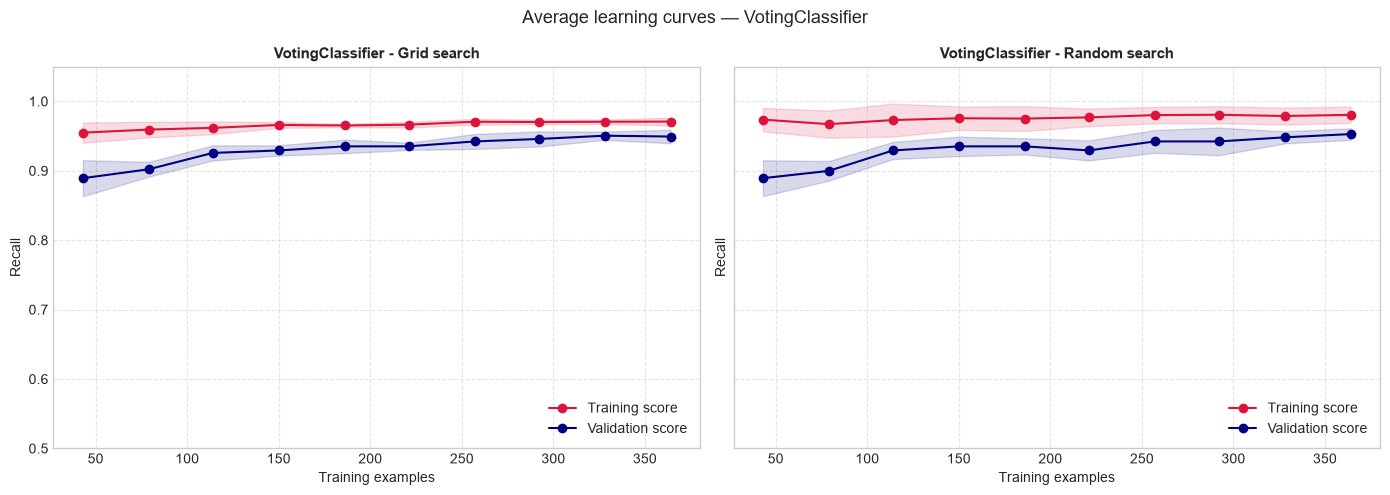

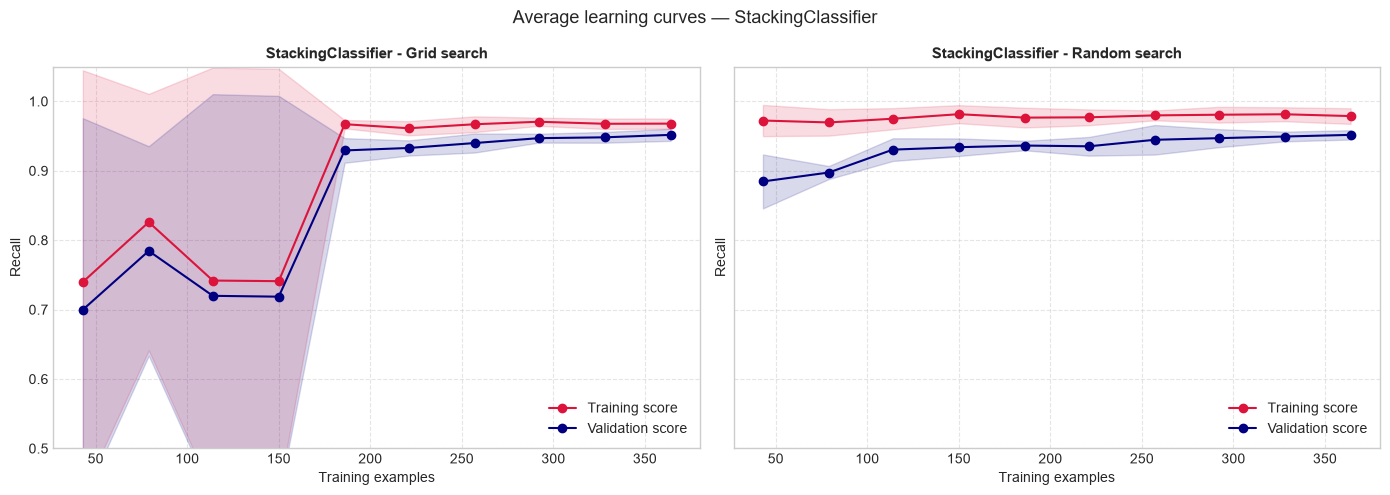

In [18]:
def plot_single_curve(ax, train_sizes, mean_train, std_train, mean_val, std_val, title, scoring):
    ax.plot(train_sizes, mean_train, "o-", color="crimson", label="Training score")
    ax.fill_between(train_sizes, mean_train - std_train, mean_train + std_train, alpha=0.15, color="crimson")

    ax.plot(train_sizes, mean_val, "o-", color="navy", label="Validation score")
    ax.fill_between(train_sizes, mean_val - std_val, mean_val + std_val, alpha=0.15, color="navy")

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Training examples")
    ax.set_ylabel(f"{scoring.capitalize()}")
    ax.set_ylim(0.5, 1.05)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="lower right")


train_sizes_input = np.linspace(0.12, 1.0, 10)
scoring = "recall"

for model_name in models:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for idx, search_type in enumerate(["grid", "random"]):
        subset = results.query("model == @model_name and search_type == @search_type")

        all_train_scores = []
        all_val_scores = []
        computed_train_sizes = None

        for _, row in subset.iterrows():
            model_clone = clone(row["best_estimator"])
            train_idx = row["train_indexes"]

            X_train_fold = X.iloc[train_idx]
            y_train_fold = y.iloc[train_idx]

            computed_train_sizes, tr_scores, val_scores = learning_curve(
                estimator=model_clone,
                X=X_train_fold,
                y=y_train_fold,
                train_sizes=train_sizes_input,
                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=config.RANDOM_STATE),
                scoring=scoring,
                shuffle=True,
                random_state=config.RANDOM_STATE,
                n_jobs=-1,
            )

            all_train_scores.append(np.mean(tr_scores, axis=1))
            all_val_scores.append(np.mean(val_scores, axis=1))

        mean_train = np.mean(all_train_scores, axis=0)
        std_train = np.std(all_train_scores, axis=0)
        mean_val = np.mean(all_val_scores, axis=0)
        std_val = np.std(all_val_scores, axis=0)

        plot_single_curve(
            ax=axes[idx],
            train_sizes=computed_train_sizes,
            mean_train=mean_train,
            std_train=std_train,
            mean_val=mean_val,
            std_val=std_val,
            title=f"{model_name} - {search_type.capitalize()} search",
            scoring=scoring,
        )

    plt.suptitle(f"Average learning curves — {model_name}", fontsize=13)
    plt.tight_layout()
    plt.show(fig)

## 1.5 Tempi di inferenza

Si riportano i tempi medi di inferenza per ciascun modello, sia sull'intero dataset sia normalizzati per singola istanza. Questo confronto è rilevante in vista di un eventuale utilizzo del modello in un contesto applicativo, quello sanitario, dove la velocità di risposta ha un peso pratico, oltre alla sola accuratezza predittiva.

In [20]:
# tempi di inferenza medio su tutto il dataset
results.groupby("model")["inference_time_seconds"].mean()

model
KNeighborsClassifier      0.00291
LogisticRegression        0.00205
RandomForestClassifier    0.00589
SVC                       0.00230
StackingClassifier        0.01019
VotingClassifier          0.01143
Name: inference_time_seconds, dtype: float64

In [21]:
# tempi di inferenza medio per singola istanza
results.groupby("model")["inference_time_seconds"].mean() / len(df)

model
KNeighborsClassifier      0.000005
LogisticRegression        0.000004
RandomForestClassifier    0.000010
SVC                       0.000004
StackingClassifier        0.000018
VotingClassifier          0.000020
Name: inference_time_seconds, dtype: float64

# 2. Tuning soglia decisionale

Con l'obiettivo di ridurre i falsi negativi, per ogni fold dell'outer loop:
- Si allena un `TunedThresholdClassifierCV` sull'outer train set per individuare la soglia ottimale che massimizza l'`F2-Score`, cercando di massimizzare la recall senza diminuire troppo la precision.
- Si applica la nuova soglia alle probabilità out-of-fold (`y_proba`) per ricalcolare le nuove metriche sull'outer test set.

In [24]:
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

tuned_thresholds = []
new_recalls = []
new_precisions = []
new_accuracies = []
new_f1s = []
new_f2s = []

for _, row in results.iterrows():
    train_idx = row["train_indexes"]
    y_test = row["y_true"]
    y_test_proba = row["y_proba"]

    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]

    tuned_model = TunedThresholdClassifierCV(
        estimator=clone(row["best_estimator"]),
        scoring=f2_scorer,
        cv=inner_cv,
        thresholds=100,
        random_state=config.RANDOM_STATE,
        n_jobs=-1,
    )

    tuned_model.fit(X_train_fold, y_train_fold)

    best_thresh = float(tuned_model.best_threshold_)
    tuned_thresholds.append(best_thresh)

    y_pred_new = (y_test_proba >= best_thresh).astype(int)

    new_recalls.append(recall_score(y_test, y_pred_new))
    new_precisions.append(precision_score(y_test, y_pred_new))
    new_accuracies.append(accuracy_score(y_test, y_pred_new))
    new_f1s.append(f1_score(y_test, y_pred_new))
    new_f2s.append(fbeta_score(y_test, y_pred_new, beta=2))

results["tuned_threshold"] = tuned_thresholds
results["recall_tuned"] = new_recalls
results["precision_tuned"] = new_precisions
results["accuracy_tuned"] = new_accuracies
results["f1_tuned"] = new_f1s
results["f2_tuned"] = new_f2s

In [38]:
results.groupby("model")[['recall', 'recall_tuned', 'precision', 'precision_tuned', 'tuned_threshold']].mean()

,recall,recall_tuned,precision,precision_tuned,tuned_threshold
model,,,,,
KNeighborsClassifier,0.9175,0.924474,0.9485,0.930866,0.396970
LogisticRegression,0.9574,0.966999,0.9628,0.960271,0.445471
RandomForestClassifier,0.9458,0.962403,0.9396,0.896995,0.378879
SVC,0.9456,0.962292,0.9568,0.942403,0.334353
StackingClassifier,0.9527,0.966888,0.9825,0.953990,0.311510
VotingClassifier,0.9457,0.976412,0.9794,0.945154,0.359745


In [28]:
# distribuzione della threshold trovata
results['tuned_threshold'].describe()

count    60.000000
mean      0.371155
std       0.101395
min       0.141960
25%       0.300559
50%       0.378959
75%       0.454596
max       0.565657
Name: tuned_threshold, dtype: float64

In [27]:
# soglia media per modello
results.groupby("model")['tuned_threshold'].mean()

model
KNeighborsClassifier      0.396970
LogisticRegression        0.445471
RandomForestClassifier    0.378879
SVC                       0.334353
StackingClassifier        0.311510
VotingClassifier          0.359745
Name: tuned_threshold, dtype: float64

In [35]:
# differenza, raggrupata per modello, tra le nuove prestazioni
# (a seguito del tuning della threshold) e le vecchie

results['recall_diff'] = results['recall_tuned'] - results['recall']
results['precision_diff'] = results['precision_tuned'] - results['precision']
results['absolute_diff'] = results['recall_diff'] + results['precision_diff']

diff = results.groupby("model")[['recall_diff', 'precision_diff', 'absolute_diff']].mean()
diff

,recall_diff,precision_diff,absolute_diff
model,,,
KNeighborsClassifier,0.006974,-0.017634,-0.010660
LogisticRegression,0.009599,-0.002529,0.007070
RandomForestClassifier,0.016603,-0.042605,-0.026002
SVC,0.016692,-0.014397,0.002296
StackingClassifier,0.014188,-0.028510,-0.014322
VotingClassifier,0.030712,-0.034246,-0.003534


# 3. Explainability

In [40]:
base_model_results = results[~results['model'].isin(['VotingClassifier', 'StackingClassifier'])]
base_model_results['model'].unique(), base_model_results.shape

(<ArrowStringArray>
 ['SVC', 'RandomForestClassifier', 'KNeighborsClassifier',
  'LogisticRegression']
 Length: 4, dtype: str,
 (40, 31))

## 3.1 Analisi stabilità feature

Per ciascun modello di base si calcola la frequenza con cui ogni feature supera il test di Welch attraverso i diversi fold e strategie di ricerca. Una feature selezionata con frequenza elevata è considerata stabile, cioè discriminante in modo consistente indipendentemente dal particolare split dei dati; una frequenza bassa suggerisce invece che la sua selezione possa dipendere più dal campionamento del fold che da un reale potere discriminante.

In [46]:
# ci si salva, per ogni modello di base, la frequenza di ciascuna feature che supera il test di Welch
welch_frequencies = {}

for model in base_model_results['model'].unique():
    subset = base_model_results.query("model == @model")
    welch_frequencies[model] = {}

    for index, row in subset.iterrows():
        features = row['welch_selected_features']
        for feature in features:
            if feature not in welch_frequencies[model].keys():
                welch_frequencies[model][feature] = 1
            else:
                welch_frequencies[model][feature] += 1

welch_frequencies

{'SVC': {'mean_concave_points': 8,
  'worst_area': 8,
  'perimeter_error': 8,
  'mean_texture': 10,
  'worst_smoothness': 10,
  'concave_points_error': 10,
  'worst_symmetry': 8,
  'mean_smoothness': 8,
  'mean_symmetry': 5,
  'worst_fractal_dimension': 2,
  'compactness_error': 4,
  'concavity_error': 3,
  'smoothness_error': 1,
  'mean_radius': 2,
  'worst_concavity': 2,
  'area_error': 2},
 'RandomForestClassifier': {'mean_concave_points': 8,
  'worst_area': 8,
  'perimeter_error': 8,
  'mean_texture': 10,
  'worst_smoothness': 9,
  'concave_points_error': 10,
  'worst_symmetry': 8,
  'mean_smoothness': 8,
  'mean_symmetry': 7,
  'worst_fractal_dimension': 3,
  'compactness_error': 2,
  'concavity_error': 2,
  'mean_radius': 2,
  'worst_concavity': 2,
  'area_error': 2},
 'KNeighborsClassifier': {'mean_concave_points': 8,
  'worst_area': 8,
  'perimeter_error': 8,
  'mean_texture': 8,
  'worst_smoothness': 7,
  'concave_points_error': 9,
  'worst_symmetry': 6,
  'mean_smoothness': 4

In [47]:
freq_df = pd.DataFrame(welch_frequencies).fillna(0)
freq_df['frequence'] = freq_df.sum(axis=1)
freq_df['frequence_percentage'] = freq_df['frequence'] / len(base_model_results) * 100
freq_df = freq_df.sort_values(by="frequence_percentage", ascending=False)
freq_df

,SVC,RandomForestClassifier,KNeighborsClassifier,LogisticRegression,frequence,frequence_percentage
concave_points_error,10,10.0,9,10.0,39.0,97.5
mean_texture,10,10.0,8,10.0,38.0,95.0
worst_smoothness,10,9.0,7,10.0,36.0,90.0
mean_concave_points,8,8.0,8,8.0,32.0,80.0
perimeter_error,8,8.0,8,8.0,32.0,80.0
worst_area,8,8.0,8,8.0,32.0,80.0
worst_symmetry,8,8.0,6,7.0,29.0,72.5
mean_smoothness,8,8.0,4,8.0,28.0,70.0
mean_symmetry,5,7.0,4,4.0,20.0,50.0
compactness_error,4,2.0,1,2.0,9.0,22.5


## 3.2 Spazio delle feature

Si analizza la dimensionalità effettiva su cui lavora ciascun modello di base dopo la selezione tramite test di Welch, sia in media sia in funzione della strategia di ricerca (Grid vs Random). Si osserva inoltre la distribuzione del parametro welch__percentage (percentuale di feature selezionate rispetto a quelle che superano il test), individuando il caso più estremo per ispezionare quali feature vengono mantenute quando la soglia è più permissiva.

In [48]:
base_model_results['n_input_features'] = base_model_results['welch_selected_features'].apply(len)

In [49]:
# numero di dimensioni medie su cui lavora ciascun modello di base
base_model_results.groupby("model")['n_input_features'].mean()

model
KNeighborsClassifier      7.2
LogisticRegression        8.3
RandomForestClassifier    8.9
SVC                       9.1
Name: n_input_features, dtype: float64

In [50]:
# numero di dimensioni medie su cui lavora ciascun modello di base in funzione della search type
base_model_results.groupby(["model", "search_type"])['n_input_features'].mean()

model                   search_type
KNeighborsClassifier    grid           7.8
                        random         6.6
LogisticRegression      grid           8.4
                        random         8.2
RandomForestClassifier  grid           9.0
                        random         8.8
SVC                     grid           9.8
                        random         8.4
Name: n_input_features, dtype: float64

In [56]:
# percentuale di feature selezionate da tutte quelle che passano il test di Welch
base_model_results['welch__percentage'] = base_model_results['best_params'].apply(
    lambda d: round(d['welch__percentage'], 4)
)

In [57]:
# distribuzione welch__percentage per modello e search type
base_model_results.groupby(['model', 'search_type'])['welch__percentage'].agg(["mean", "min", "max"])

mean     min     max
model                  search_type                         
KNeighborsClassifier   grid         0.66000  0.3000  1.0000
                       random       0.57106  0.3504  0.7925
LogisticRegression     grid         0.72000  0.5000  0.9000
                       random       0.72904  0.5332  0.9106
RandomForestClassifier grid         0.78000  0.5000  0.9000
                       random       0.76910  0.4564  0.9783
SVC                    grid         0.82000  0.6000  1.0000
                       random       0.70776  0.5203  0.8758

In [66]:
# stampa delle feature selezionate nel caso più estremo (welch__percentage == 0.3)
base_model_results.query("welch__percentage == 0.3000")['welch_selected_features']

22    [mean_concave_points, worst_area, perimeter_er...
Name: welch_selected_features, dtype: object

## 3.3 Feature importance

### 3.3.1 SHAP (SHapley Additive exPlanation)

A differenza della feature importance nativa, i valori SHAP quantificano il contributo di ciascuna feature alla singola predizione e sono confrontabili tra modelli di natura diversa (lineari, ad albero, kernel-based). Si riporta il valore assoluto medio degli SHAP value per ciascuna feature, per ogni modello e strategia di ricerca, oltre a un beeswarm plot di dettaglio per il modello SVC con Grid Search.

In [76]:
def compute_shap(results_df: pd.DataFrame, X: pd.DataFrame, models: list[str] | None = None,
                search_types: list[str] | None = None, force_recompute: bool = False,
                filename: str = "shap_results.pkl") -> dict[tuple[str, str], shap.Explanation]:

    models = models or results_df["model"].unique().tolist()
    search_types = search_types or results_df["search_type"].unique().tolist()

    output_path = config.DATA_DIR / filename
    if output_path.exists() and not force_recompute:
        print(f"Loading explanation from {output_path}")
        with open(output_path, "rb") as f:
            return pickle.load(f)

    explanations = {}

    for model in models:
        for search_type in search_types:
            subset = results_df.query("model == @model and search_type == @search_type")
            if subset.empty:
                continue

            print(f"Elaborating shap for {model} | {search_type} search")

            oof_shap_matrices = []
            oof_base_values = []
            oof_test_indices = []

            for _, row in subset.iterrows():
                train_idx = row["train_indexes"]
                test_idx = row["test_indexes"]
                pipeline = row["best_estimator"]

                X_train_fold = X.iloc[train_idx]
                X_test_fold = X.iloc[test_idx]

                n_bg = min(100, len(X_train_fold))
                background = shap.sample(X_train_fold, n_bg, random_state=config.RANDOM_STATE)

                def predict_fn(data):
                    return pipeline.predict_proba(pd.DataFrame(data, columns=X.columns))[:, 1]

                explainer = shap.KernelExplainer(predict_fn, background)
                shap_vals = explainer.shap_values(X_test_fold, nsamples=100)

                ev = explainer.expected_value
                if isinstance(ev, (list, np.ndarray)):
                    ev = ev[1] if len(ev) > 1 else ev[0]

                oof_shap_matrices.append(shap_vals)
                oof_test_indices.append(test_idx)
                oof_base_values.append(np.full(len(test_idx), ev))

            all_shap = np.vstack(oof_shap_matrices)
            all_bases = np.concatenate(oof_base_values)
            all_indices = np.concatenate(oof_test_indices)
            sort_order = np.argsort(all_indices)

            exp = shap.Explanation(
                values=all_shap[sort_order].astype(np.float64),
                base_values=all_bases[sort_order].astype(np.float64),
                data=X.iloc[all_indices[sort_order]].values,
                feature_names=X.columns.tolist(),
            )

            explanations[(model, search_type)] = exp

    print(f"Saving results to {output_path}")
    with open(output_path, "wb") as f:
        pickle.dump(explanations, f, protocol=pickle.HIGHEST_PROTOCOL)

    return explanations

In [77]:
shap_explanations = compute_shap(results_df=results, X=X)

Loading explanation from C:\Users\raffa\PycharmProjects\master\1year\2sem\FDSML-TEAM-2\data\shap_results.pkl


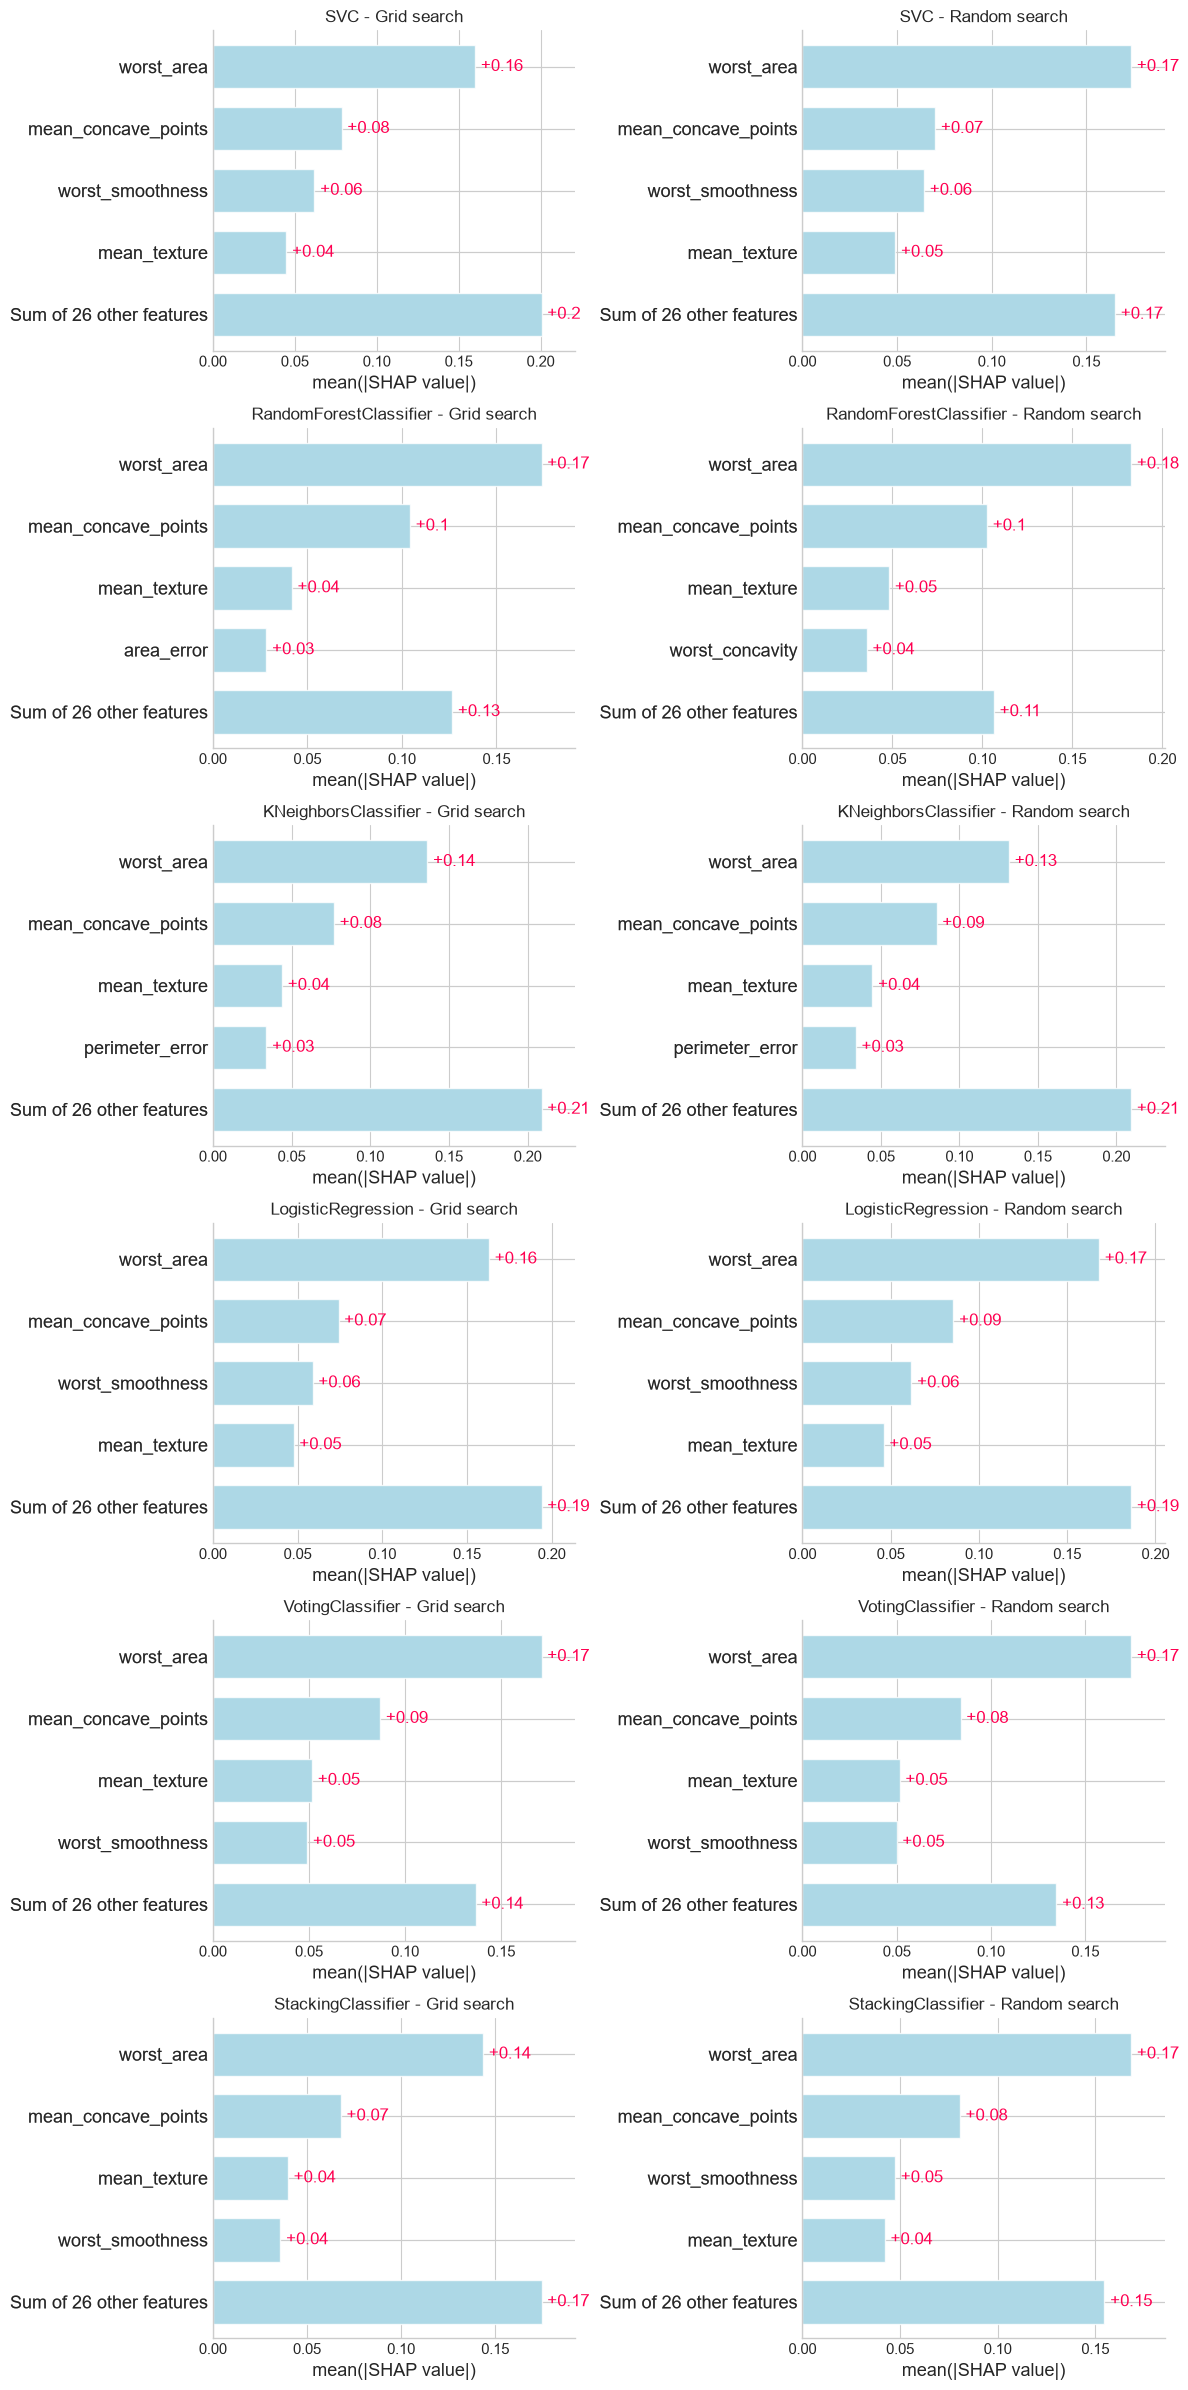

In [80]:
# per ogni modello, per ogni search type, si plotta il valore assoluto dello shap value di ogni feature
fig, axes = plt.subplots(
    nrows=len(models),
    ncols=len(search_types),
    figsize=(6 * len(search_types), 4 * len(models)),
    squeeze=False
)

for i, model_name in enumerate(models):
    for j, search_type in enumerate(search_types):
        ax = axes[i, j]

        explanation = shap_explanations[(model_name, search_type)]

        shap.plots.bar(explanation, max_display=5, show=False, ax=ax)

        for patch in ax.patches:
            patch.set_facecolor("lightblue")

        ax.set_title(f"{model_name} - {search_type.capitalize()} search")

plt.tight_layout()
plt.show(fig)

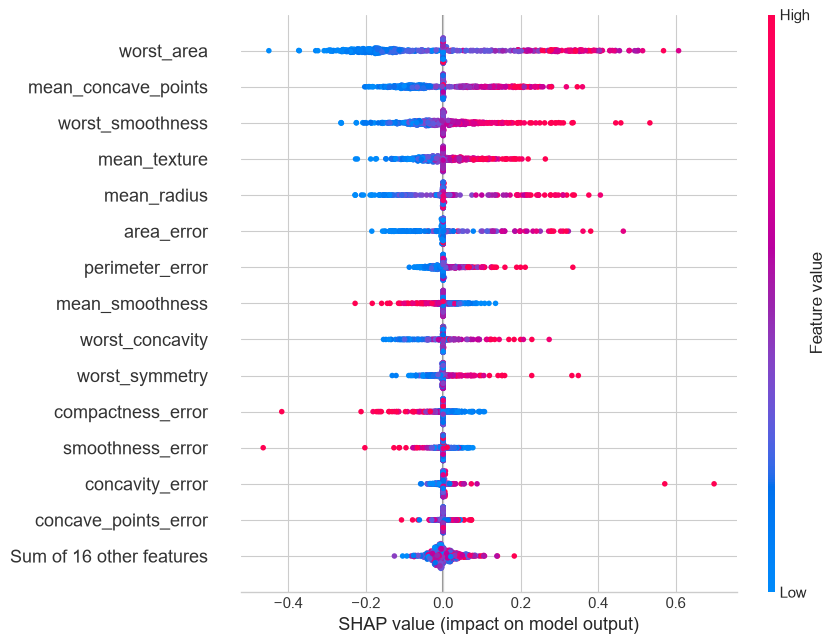

In [81]:
# beeswarm plot del modello SVC con search type = 'grid'
shap.plots.beeswarm(
    shap_explanations[('SVC', 'grid')],
    max_display=15,
)

### 3.3.2. Model specific

Di seguito sono riportate le feature importance native di Random Forest Classifier e Logistic Regression, ciascuna calcolata secondo la propria logica intrinseca: impurity-based (riduzione media dell'impurità) per Random Forest, coefficienti per Logistic Regression.

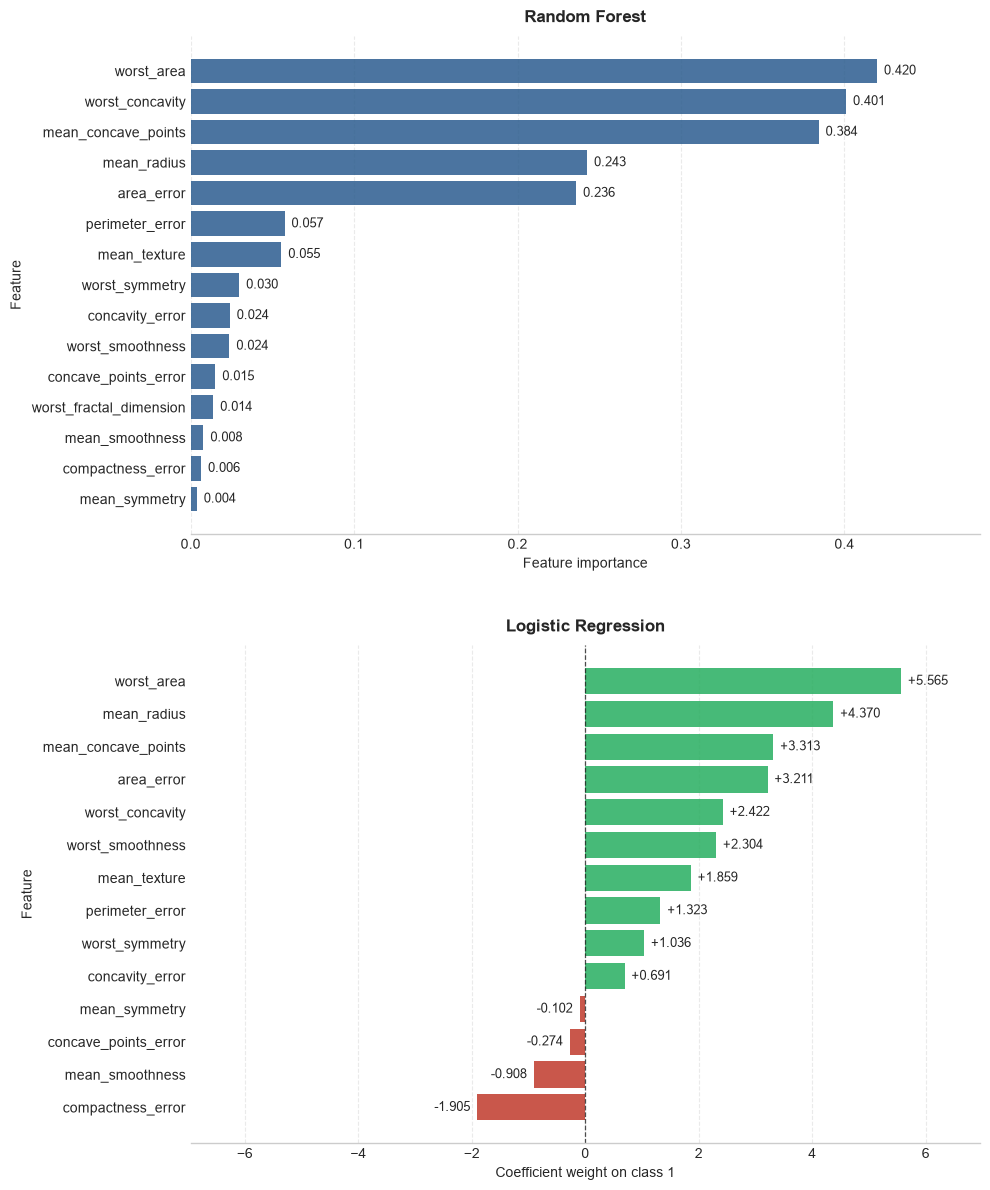

In [86]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 12),
    sharex=False,
)

rf_dict = {}
for _, row in results.query("model == 'RandomForestClassifier'").iterrows():
    est = row["best_estimator"][-1]
    for feature, importance in zip(est.feature_names_in_, est.feature_importances_):
        rf_dict.setdefault(feature, []).append(importance)

rf_mean = pd.Series({f: np.mean(v) for f, v in rf_dict.items()}).sort_values(ascending=True)

bars_rf = axes[0].barh(rf_mean.index, rf_mean.values, color="#2b5c8f", alpha=0.85)
axes[0].bar_label(bars_rf, labels=[f"{v:.3f}" for v in rf_mean.values], padding=5, fontsize=9)
axes[0].set_title("Random Forest", fontsize=12, fontweight="bold", pad=10)
axes[0].set_xlabel("Feature importance", fontsize=10)
axes[0].set_xlim(0, rf_mean.max() * 1.15)


lr_dict = {}
for _, row in results.query("model == 'LogisticRegression'").iterrows():
    est = row["best_estimator"][-1]
    for feature, coefficient in zip(est.feature_names_in_, est.coef_[0]):
        lr_dict.setdefault(feature, []).append(coefficient)

lr_mean = pd.Series({f: np.mean(v) for f, v in lr_dict.items()}).sort_values(ascending=True)

bar_colors = ["#c0392b" if v < 0 else "#27ae60" for v in lr_mean.values]
bars_lr = axes[1].barh(lr_mean.index, lr_mean.values, color=bar_colors, alpha=0.85)
axes[1].bar_label(bars_lr, labels=[f"{v:+.3f}" for v in lr_mean.values], padding=5, fontsize=9)
axes[1].axvline(0, color="#222222", linestyle="--", linewidth=0.9, alpha=0.8)

axes[1].set_title("Logistic Regression", fontsize=12, fontweight="bold", pad=10)
axes[1].set_xlabel("Coefficient weight on class 1", fontsize=10)

max_abs = np.abs(lr_mean.values).max() * 1.25
axes[1].set_xlim(-max_abs, max_abs)

for ax in axes:
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.grid(axis="y", visible=False)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#cccccc")
    ax.set_ylabel("Feature", fontsize=10, labelpad=6)

plt.tight_layout(h_pad=3.5)
plt.show()